# Kaggriculture Opening Book: First 48 Turns

The first two days reveal plenty: seed choice, early hires, land purchases and whether a farmer has a plan or merely excellent cardio.

This notebook compresses strong openings into readable sequences and a small set of opening styles.

In [1]:
from __future__ import annotations

import json
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def replay_files() -> list[Path]:
    configured = os.environ.get("KAGGRICULTURE_REPLAY_DIR")
    roots = []
    if configured:
        roots.append(Path(configured))
    roots.extend([
        Path("/kaggle/input/kaggriculture-episodes-2026-07-30"),
        Path("/kaggle/input"),
        Path("research/sample_replay"),
    ])
    seen = set()
    files = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("*.json"):
            if path.name in {"dataset-metadata.json", "kernel-metadata.json"}:
                continue
            key = str(path.resolve())
            if key not in seen:
                seen.add(key)
                files.append(path)
        if files:
            break
    return sorted(files, key=lambda p: int(p.stem) if p.stem.isdigit() else p.stem)


def _value_after_key(raw: bytes, key: bytes):
    start = raw.find(key)
    if start < 0:
        return None
    colon = raw.find(b":", start + len(key))
    if colon < 0:
        return None
    text = raw[colon + 1 :].decode("utf-8", errors="ignore").lstrip()
    try:
        return json.JSONDecoder().raw_decode(text)[0]
    except (json.JSONDecodeError, UnicodeDecodeError):
        return None


def replay_header(path: Path) -> dict:
    raw = b""
    with path.open("rb") as stream:
        for limit in (131_072, 524_288, 1_048_576):
            raw += stream.read(limit - len(raw))
            teams = _value_after_key(raw, b'"TeamNames"')
            rewards = _value_after_key(raw, b'"rewards"')
            episode_id = _value_after_key(raw, b'"EpisodeId"')
            if teams is not None and rewards is not None:
                break
    teams = list(teams or [])
    rewards = list(rewards or [])
    while len(teams) < 2:
        teams.append(f"Player {len(teams)}")
    while len(rewards) < 2:
        rewards.append(np.nan)
    clean_rewards = [float(x) if x is not None else np.nan for x in rewards[:2]]
    return {
        "episode_id": int(episode_id or (int(path.stem) if path.stem.isdigit() else -1)),
        "path": str(path),
        "player_0": teams[0],
        "player_1": teams[1],
        "reward_0": clean_rewards[0],
        "reward_1": clean_rewards[1],
        "avg_reward": float(np.nanmean(clean_rewards)),
        "winner": teams[int(np.nanargmax(clean_rewards))] if not np.all(np.isnan(clean_rewards)) and clean_rewards[0] != clean_rewards[1] else "Tie",
    }


def replay_index(files: list[Path]) -> pd.DataFrame:
    rows = [replay_header(path) for path in files]
    return pd.DataFrame(rows).sort_values(["avg_reward", "episode_id"], ascending=[False, True]).reset_index(drop=True)


def load_replay(path: str | Path) -> dict:
    with Path(path).open("r", encoding="utf-8") as stream:
        return json.load(stream)


def operation_name(action) -> str:
    if isinstance(action, list) and action:
        return str(action[0])
    if isinstance(action, str):
        return action
    return "PASS"


def show(frame: pd.DataFrame, rows: int = 12):
    try:
        from IPython.display import display
        display(frame.head(rows))
    except ImportError:
        print(frame.head(rows).to_string(index=False))


def save(frame: pd.DataFrame, name: str):
    path = OUTPUT_DIR / name
    frame.to_csv(path, index=False)
    print(f"Saved {len(frame):,} rows -> {path}")
    return path

Saved 80 rows -> /kaggle/working/opening_book.csv
Saved 1,120 rows -> /kaggle/working/opening_sequences.csv


,episode_id,team,player,final_reward,won,style,favorite_crop,seed_units_bought,hires,land_buys,animal_units_bought,opening_sequence
55,89023208,Victor Mercklé,1,157449.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
3,89041538,Victor Mercklé @ Tufa Labs,1,145307.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
52,89022740,Victor Mercklé,0,143235.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
79,89024567,Victor Mercklé,1,137288.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
26,89040614,Victor Mercklé @ Tufa Labs,0,136954.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
42,89025931,Victor Mercklé,0,136248.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
24,89035091,Victor Mercklé,0,133829.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
38,89026844,Victor Mercklé,0,133681.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
44,89022742,Victor Mercklé,0,132377.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...
18,89043372,Victor Mercklé @ Tufa Labs,0,132186.0,True,Land rush,CARROT,39,14,1,0,M:BUY_LAND: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:HIRE: -> M:BUY_SEED:MELON -> M:BU...


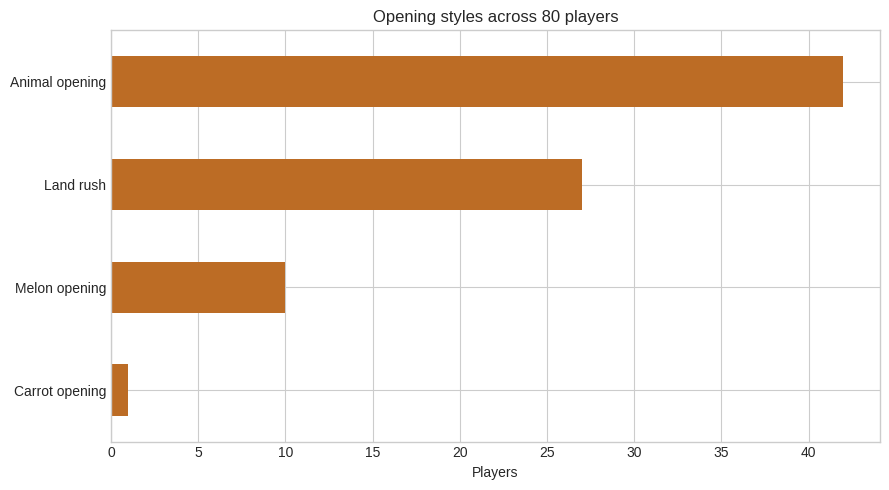

,favorite_crop,players,median_reward,win_rate
0,CARROT,15,133681.0,86.7
1,MELON,59,87744.0,45.8
2,NONE,1,59576.0,0.0
3,WHEAT,5,35058.0,0.0


In [2]:
TOP_REPLAYS = 40
OPENING_TURNS = 48

files = replay_files()
index = replay_index(files)
selected = index.head(min(TOP_REPLAYS, len(index)))
rows = []
sequence_rows = []

for meta in selected.itertuples(index=False):
    replay = load_replay(meta.path)
    teams = list(replay.get("info", {}).get("TeamNames", [meta.player_0, meta.player_1]))
    rewards = list(replay.get("rewards", [meta.reward_0, meta.reward_1]))
    steps = replay.get("steps", [])[:OPENING_TURNS]
    for player_id, team in enumerate(teams[:2]):
        market = Counter()
        farmer = Counter()
        sequence = []
        for step_id, states in enumerate(steps):
            action = states[player_id].get("action") or {}
            if not isinstance(action, dict):
                action = {"farmer": action}
            farmer_op = operation_name(action.get("farmer"))
            farmer[farmer_op] += 1
            if farmer_op != "PASS" and len(sequence) < 14:
                sequence.append(f"F:{farmer_op}")
            for order in action.get("market") or []:
                if not isinstance(order, list) or not order:
                    continue
                op = str(order[0])
                item = str(order[1]) if len(order) > 1 else ""
                quantity = order[2] if len(order) > 2 else 1
                market[(op, item)] += int(quantity) if isinstance(quantity, (int, float)) else 1
                if len(sequence) < 14:
                    sequence.append(f"M:{op}:{item}")

        seed_buys = {item: amount for (op, item), amount in market.items() if op == "BUY_SEED"}
        animal_buys = sum(amount for (op, _), amount in market.items() if op == "BUY_ANIMAL")
        land_buys = sum(amount for (op, _), amount in market.items() if op == "BUY_LAND")
        hires = sum(amount for (op, _), amount in market.items() if op == "HIRE")
        favorite_crop = max(seed_buys, key=seed_buys.get) if seed_buys else "NONE"
        if land_buys:
            style = "Land rush"
        elif animal_buys or farmer["BUILD_COOP"] or farmer["BUILD_PASTURE"]:
            style = "Animal opening"
        elif favorite_crop != "NONE":
            style = f"{favorite_crop.title()} opening"
        else:
            style = "Quiet opening"

        rows.append({
            "episode_id": meta.episode_id,
            "team": team,
            "player": player_id,
            "final_reward": rewards[player_id],
            "won": rewards[player_id] > rewards[1 - player_id],
            "style": style,
            "favorite_crop": favorite_crop,
            "seed_units_bought": sum(seed_buys.values()),
            "hires": hires,
            "land_buys": land_buys,
            "animal_units_bought": animal_buys,
            "opening_sequence": " -> ".join(sequence),
        })
        for position, event in enumerate(sequence, start=1):
            sequence_rows.append({"episode_id": meta.episode_id, "team": team, "position": position, "event": event})

openings = pd.DataFrame(rows).sort_values("final_reward", ascending=False)
sequences = pd.DataFrame(sequence_rows)
save(openings, "opening_book.csv")
save(sequences, "opening_sequences.csv")
show(openings, 20)

style_counts = openings["style"].value_counts().head(12).sort_values()
ax = style_counts.plot.barh(figsize=(9, 5), color="#bc6c25")
ax.set_title(f"Opening styles across {len(openings)} players")
ax.set_xlabel("Players")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

crop_summary = openings.groupby("favorite_crop").agg(players=("team", "size"), median_reward=("final_reward", "median"), win_rate=("won", "mean")).sort_values("median_reward", ascending=False)
crop_summary["win_rate"] = crop_summary["win_rate"].mul(100).round(1)
show(crop_summary.reset_index(), 12)

## Steal the shape, not the exact footsteps

`opening_book.csv` keeps the compact style summary. `opening_sequences.csv` keeps the early event order for deeper pattern mining.